# 03. External Validation EDA & Cleaning

**입력**: `valid/` 폴더 (4,800 파일)
**출력**:
- `data/processed/valid_maturity.csv` (Mature / Immature)
- `data/processed/valid_quality.csv` (Fresh / Rotten)

## 처리 단계
1. 전체 파일 content hash로 dedup
2. 5개 폴더 (Three/{Reject,Ripe,Unripe} + Two/{Healthy,Reject}) 간 매핑 분석
3. 라벨 충돌(같은 이미지가 모순된 라벨) 검출 & 제외
4. 2-class 라벨 매핑 (Ripe→Mature, Unripe→Immature, Healthy→Fresh, Reject→Rotten)
5. CSV 저장 + 시각화

## 1. 환경 설정

In [1]:
import hashlib
import json
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.notebook import tqdm

SEED = 42
np.random.seed(SEED)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
VALID_ROOT = PROJECT_ROOT / 'valid'
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed'
RESULTS_DIR = PROJECT_ROOT / 'results' / 'figures'
TABLES_DIR = PROJECT_ROOT / 'results' / 'tables'
for d in [DATA_PROCESSED, RESULTS_DIR, TABLES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('OK')

OK


## 2. 폴더 구조 확인

In [2]:
BUCKETS = {
    'Three/Reject':   VALID_ROOT / 'Three Classes' / 'Reject',
    'Three/Ripe':     VALID_ROOT / 'Three Classes' / 'Ripe',
    'Three/Unripe':   VALID_ROOT / 'Three Classes' / 'Unripe',
    'Two/Healthy':    VALID_ROOT / 'Two Classes'   / 'Healthy',
    'Two/Reject':     VALID_ROOT / 'Two Classes'   / 'Reject',
}

file_lists = {tag: sorted([p for p in folder.iterdir() if p.is_file()])
              for tag, folder in BUCKETS.items()}

print('=== 폴더별 파일 수 ===')
total = 0
for tag, fl in file_lists.items():
    print(f'  {tag:14s} {len(fl):>5d}')
    total += len(fl)
print(f'  {"전체":14s} {total:>5d}')

=== 폴더별 파일 수 ===
  Three/Reject     800
  Three/Ripe       800
  Three/Unripe     800
  Two/Healthy     1600
  Two/Reject       800
  전체              4800


## 3. 전체 파일 content hash (MD5)

같은 내용의 파일이 여러 경로에 존재하는지 + 내부 중복 검출.

In [3]:
def md5_of(p, chunk=1<<16):
    h = hashlib.md5()
    with open(p, 'rb') as f:
        for c in iter(lambda: f.read(chunk), b''):
            h.update(c)
    return h.hexdigest()

# hash → list of (bucket_tag, filename)
hash_to_records = defaultdict(list)

for tag, fl in file_lists.items():
    for p in tqdm(fl, desc=f'Hashing {tag}', leave=False):
        hash_to_records[md5_of(p)].append((tag, p.name))

n_unique = len(hash_to_records)
print(f'총 파일:           {total}')
print(f'고유 content hash: {n_unique}')
print(f'중복 사본:         {total - n_unique}')

Hashing Three/Reject:   0%|          | 0/800 [00:00<?, ?it/s]

Hashing Three/Ripe:   0%|          | 0/800 [00:00<?, ?it/s]

Hashing Three/Unripe:   0%|          | 0/800 [00:00<?, ?it/s]

Hashing Two/Healthy:   0%|          | 0/1600 [00:00<?, ?it/s]

Hashing Two/Reject:   0%|          | 0/800 [00:00<?, ?it/s]

총 파일:           4800
고유 content hash: 1559
중복 사본:         3241


## 4. 각 고유 이미지가 어느 버킷들에 존재하는지

In [4]:
bucket_combos = Counter()
for h, records in hash_to_records.items():
    combo = tuple(sorted({tag for tag, _ in records}))
    bucket_combos[combo] += 1

print('=== Unique image → bucket combination ===')
for combo, count in sorted(bucket_combos.items(), key=lambda x: -x[1]):
    print(f'  {count:5d}  in  {combo}')

print()
print('총 고유 이미지:', sum(bucket_combos.values()))

=== Unique image → bucket combination ===
    797  in  ('Three/Ripe', 'Two/Healthy')
    666  in  ('Three/Reject', 'Two/Reject')
     93  in  ('Three/Unripe', 'Two/Healthy')
      3  in  ('Three/Reject', 'Three/Ripe', 'Two/Healthy', 'Two/Reject')

총 고유 이미지: 1559


## 5. 라벨 충돌 검출 & 제외

같은 이미지가 모순된 라벨에 동시 등록된 경우 제외.
예: (Three/Reject + Three/Ripe + Two/Healthy + Two/Reject)에 모두 존재 → 라벨 불일치

In [5]:
# 각 hash에 대해 valid한 (maturity, quality) 라벨 결정
# Maturity: Three Classes 기준
#   - Ripe → Mature
#   - Unripe → Immature
#   - Reject → maturity 라벨 없음
# Quality: Two Classes 기준
#   - Healthy → Fresh
#   - Reject → Rotten

records = []  # final cleaned records

THREE_BUCKETS = {'Three/Reject', 'Three/Ripe', 'Three/Unripe'}
TWO_BUCKETS = {'Two/Healthy', 'Two/Reject'}

conflicts = {'maturity_conflict': [], 'quality_conflict': []}

for h, recs in hash_to_records.items():
    buckets_present = {tag for tag, _ in recs}

    # Maturity 라벨 결정
    maturity_label = None
    three_present = buckets_present & THREE_BUCKETS
    if three_present == {'Three/Ripe'}:
        maturity_label = 'Mature'
    elif three_present == {'Three/Unripe'}:
        maturity_label = 'Immature'
    elif three_present == {'Three/Reject'}:
        maturity_label = None  # Reject는 maturity 라벨 없음
    elif len(three_present) > 1:
        conflicts['maturity_conflict'].append(h)
        maturity_label = None

    # Quality 라벨 결정
    quality_label = None
    two_present = buckets_present & TWO_BUCKETS
    if two_present == {'Two/Healthy'}:
        quality_label = 'Fresh'
    elif two_present == {'Two/Reject'}:
        quality_label = 'Rotten'
    elif len(two_present) > 1:
        conflicts['quality_conflict'].append(h)
        quality_label = None

    # 대표 파일 선택 (첫 번째 record)
    rep_tag, rep_name = recs[0]
    rep_path = BUCKETS[rep_tag] / rep_name

    records.append({
        'content_hash': h,
        'rep_filepath': str(rep_path),
        'rep_bucket': rep_tag,
        'rep_filename': rep_name,
        'n_duplicates': len(recs),
        'buckets_present': '|'.join(sorted(buckets_present)),
        'maturity_label': maturity_label,
        'quality_label': quality_label,
    })

df = pd.DataFrame(records)
print(f'고유 이미지: {len(df)}')
print(f'Maturity 라벨 충돌: {len(conflicts["maturity_conflict"])}')
print(f'Quality 라벨 충돌:  {len(conflicts["quality_conflict"])}')
print()
print('=== 최종 라벨 분포 (충돌은 None) ===')
print('Maturity:', df['maturity_label'].value_counts(dropna=False).to_dict())
print('Quality: ', df['quality_label'].value_counts(dropna=False).to_dict())

고유 이미지: 1559
Maturity 라벨 충돌: 3
Quality 라벨 충돌:  3

=== 최종 라벨 분포 (충돌은 None) ===
Maturity: {'Mature': 797, nan: 669, 'Immature': 93}
Quality:  {'Fresh': 890, 'Rotten': 666, nan: 3}


## 6. 태스크별 평가 데이터셋 생성

- `valid_maturity.csv`: Maturity 라벨이 있는 행만 (Mature / Immature)
- `valid_quality.csv`: Quality 라벨이 있는 행만 (Fresh / Rotten)
- 충돌 라벨은 자동 제외 (위에서 None으로 마킹된 것)

In [6]:
valid_maturity = df[df['maturity_label'].notna()][
    ['content_hash', 'rep_filepath', 'rep_filename', 'maturity_label', 'n_duplicates', 'buckets_present']
].rename(columns={'maturity_label': 'class_label'}).reset_index(drop=True)

valid_quality = df[df['quality_label'].notna()][
    ['content_hash', 'rep_filepath', 'rep_filename', 'quality_label', 'n_duplicates', 'buckets_present']
].rename(columns={'quality_label': 'class_label'}).reset_index(drop=True)

valid_maturity['task'] = 'maturity'
valid_quality['task'] = 'quality'

print('=== valid_maturity ===')
print(valid_maturity['class_label'].value_counts())
print(f'  Total: {len(valid_maturity)}')
print()
print('=== valid_quality ===')
print(valid_quality['class_label'].value_counts())
print(f'  Total: {len(valid_quality)}')

=== valid_maturity ===
class_label
Mature      797
Immature     93
Name: count, dtype: int64
  Total: 890

=== valid_quality ===
class_label
Fresh     890
Rotten    666
Name: count, dtype: int64
  Total: 1556


## 7. 시각화 — 클래스 분포

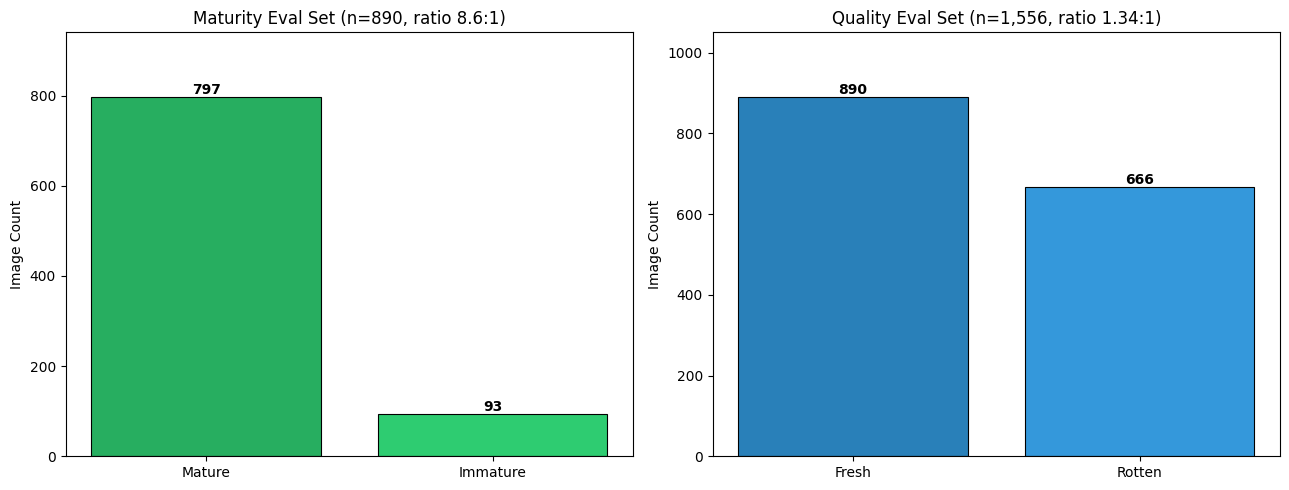

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Maturity
ax = axes[0]
counts_m = valid_maturity['class_label'].value_counts()
colors_m = ['#27ae60', '#2ecc71']
bars = ax.bar(counts_m.index, counts_m.values, color=colors_m, edgecolor='black', linewidth=0.8)
for bar, v in zip(bars, counts_m.values):
    ax.text(bar.get_x()+bar.get_width()/2, v, f'{v:,}',
            ha='center', va='bottom', fontweight='bold')
ratio_m = counts_m.max() / counts_m.min()
ax.set_title(f'Maturity Eval Set (n={len(valid_maturity):,}, ratio {ratio_m:.1f}:1)')
ax.set_ylabel('Image Count')
ax.set_ylim(0, counts_m.max() * 1.18)

# Quality
ax = axes[1]
counts_q = valid_quality['class_label'].value_counts()
colors_q = ['#2980b9', '#3498db']
bars = ax.bar(counts_q.index, counts_q.values, color=colors_q, edgecolor='black', linewidth=0.8)
for bar, v in zip(bars, counts_q.values):
    ax.text(bar.get_x()+bar.get_width()/2, v, f'{v:,}',
            ha='center', va='bottom', fontweight='bold')
ratio_q = counts_q.max() / counts_q.min()
ax.set_title(f'Quality Eval Set (n={len(valid_quality):,}, ratio {ratio_q:.2f}:1)')
ax.set_ylabel('Image Count')
ax.set_ylim(0, counts_q.max() * 1.18)

plt.tight_layout()
plt.savefig(RESULTS_DIR / '08_valid_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. 샘플 이미지 (각 클래스 4장)

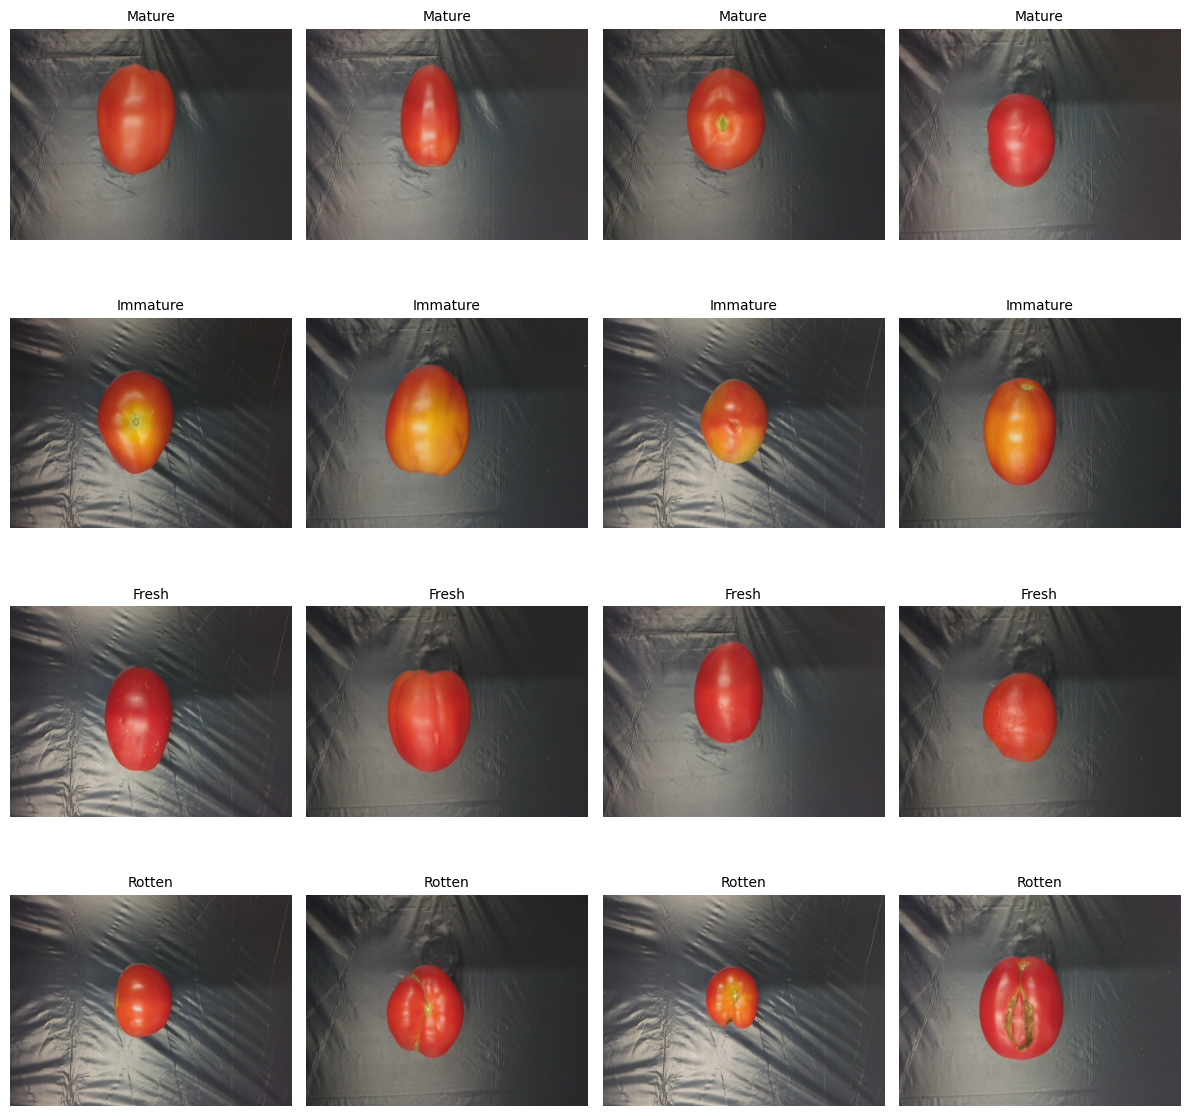

In [8]:
fig, axes = plt.subplots(4, 4, figsize=(12, 12))

panels = [
    ('Mature',   valid_maturity[valid_maturity['class_label']=='Mature']),
    ('Immature', valid_maturity[valid_maturity['class_label']=='Immature']),
    ('Fresh',    valid_quality[valid_quality['class_label']=='Fresh']),
    ('Rotten',   valid_quality[valid_quality['class_label']=='Rotten']),
]

for row, (label, subset) in enumerate(panels):
    samples = subset.sample(n=min(4, len(subset)), random_state=SEED)
    for col, (_, r) in enumerate(samples.iterrows()):
        try:
            img = Image.open(r['rep_filepath']).convert('RGB')
            axes[row, col].imshow(img)
            axes[row, col].set_title(f'{label}', fontsize=10)
        except Exception as e:
            axes[row, col].text(0.5, 0.5, 'Err', ha='center')
        axes[row, col].axis('off')

plt.tight_layout()
plt.savefig(RESULTS_DIR / '09_valid_samples.png', dpi=120, bbox_inches='tight')
plt.show()

## 9. CSV 저장 + 메타정보

In [9]:
# CSV 저장
mat_path = DATA_PROCESSED / 'valid_maturity.csv'
qual_path = DATA_PROCESSED / 'valid_quality.csv'
valid_maturity.to_csv(mat_path, index=False)
valid_quality.to_csv(qual_path, index=False)
print(f'✅ {mat_path}  ({len(valid_maturity):,} rows)')
print(f'✅ {qual_path} ({len(valid_quality):,} rows)')

# 메타정보
meta = {
    'source_folder': str(VALID_ROOT.relative_to(PROJECT_ROOT)),
    'raw_files': int(total),
    'unique_images_by_hash': int(len(df)),
    'duplicate_copies_removed': int(total - len(df)),
    'label_conflicts_excluded': {
        'maturity_conflicts': len(conflicts['maturity_conflict']),
        'quality_conflicts': len(conflicts['quality_conflict']),
    },
    'maturity': {
        'total': int(len(valid_maturity)),
        'Mature': int((valid_maturity['class_label']=='Mature').sum()),
        'Immature': int((valid_maturity['class_label']=='Immature').sum()),
        'class_mapping': 'Three Classes/Ripe→Mature, Three Classes/Unripe→Immature, Reject excluded',
    },
    'quality': {
        'total': int(len(valid_quality)),
        'Fresh': int((valid_quality['class_label']=='Fresh').sum()),
        'Rotten': int((valid_quality['class_label']=='Rotten').sum()),
        'class_mapping': 'Two Classes/Healthy→Fresh, Two Classes/Reject→Rotten',
    },
    'dedup_method': 'MD5 content hash (full file)',
    'notes': [
        '같은 이미지가 여러 폴더에 중복 저장되어 있어 hash 기반 dedup 적용',
        '라벨 충돌(같은 이미지가 상호 배타적 폴더에 동시 등록) 자동 제외',
        '대표 파일(rep_filepath)은 hash group의 첫 번째 발견 경로',
    ],
}
meta_path = DATA_PROCESSED / 'valid_meta.json'
meta_path.write_text(json.dumps(meta, indent=2, ensure_ascii=False), encoding='utf-8')
print(f'✅ {meta_path}')
print()
print('--- 메타 요약 ---')
print(json.dumps(meta, indent=2, ensure_ascii=False))

✅ C:\Users\smin\IdeaProjects\tomato\data\processed\valid_maturity.csv  (890 rows)
✅ C:\Users\smin\IdeaProjects\tomato\data\processed\valid_quality.csv (1,556 rows)
✅ C:\Users\smin\IdeaProjects\tomato\data\processed\valid_meta.json

--- 메타 요약 ---
{
  "source_folder": "valid",
  "raw_files": 4800,
  "unique_images_by_hash": 1559,
  "duplicate_copies_removed": 3241,
  "label_conflicts_excluded": {
    "maturity_conflicts": 3,
    "quality_conflicts": 3
  },
  "maturity": {
    "total": 890,
    "Mature": 797,
    "Immature": 93,
    "class_mapping": "Three Classes/Ripe→Mature, Three Classes/Unripe→Immature, Reject excluded"
  },
  "quality": {
    "total": 1556,
    "Fresh": 890,
    "Rotten": 666,
    "class_mapping": "Two Classes/Healthy→Fresh, Two Classes/Reject→Rotten"
  },
  "dedup_method": "MD5 content hash (full file)",
  "notes": [
    "같은 이미지가 여러 폴더에 중복 저장되어 있어 hash 기반 dedup 적용",
    "라벨 충돌(같은 이미지가 상호 배타적 폴더에 동시 등록) 자동 제외",
    "대표 파일(rep_filepath)은 hash group의 첫 번째 발견 경로"
  ]
}


## 10. 요약

### 결과
- **valid_maturity.csv**: Maturity 평가용 (Mature / Immature)
- **valid_quality.csv**: Quality 평가용 (Fresh / Rotten)
- 모든 행이 고유 이미지 (content hash dedup 완료)
- 라벨 충돌 자동 제외

### 주의사항
- Maturity의 Immature 표본 수가 적음 → **bootstrap CI** + **macro-F1** 보고 권장
- Quality는 비교적 균형
- `rep_filepath`로 실제 이미지 로드 가능

### 다음 단계
모델 학습 + 외부 평가 노트북에서 이 CSV를 그대로 로드해서 사용.